# Heart Disease Prediction

## 4. Supervised Learning - Classification Models

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, classification_report
)

In [7]:
df = pd.read_csv("reduced_heart_disease.csv")

X = df.drop(columns=["num"])
y = df["num"] 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}

In [9]:
# Training and Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "AUC": auc
    }

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))


Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.77      0.79        82
           1       0.82      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.67      0.70        82
           1       0.75      0.79      0.77       102

    accuracy                           0.74       184
   macro avg       0.74      0.73      0.73       184
weighted avg       0.74      0.74      0.74       184


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.76      0.78        82
           1       0.81      0.84      0.83       102

    accuracy                           0.80       184
   ma

In [10]:
# Metrics Table
results_df = pd.DataFrame(results).T
print("\nModel Performance Summary:\n")
print(results_df)


Model Performance Summary:

                     Accuracy  Precision    Recall  F1-score       AUC
Logistic Regression  0.820652   0.822430  0.862745  0.842105  0.902559
Decision Tree        0.739130   0.750000  0.794118  0.771429  0.732425
Random Forest        0.804348   0.811321  0.843137  0.826923  0.907580
SVM                  0.744565   0.747748  0.813725  0.779343  0.773912


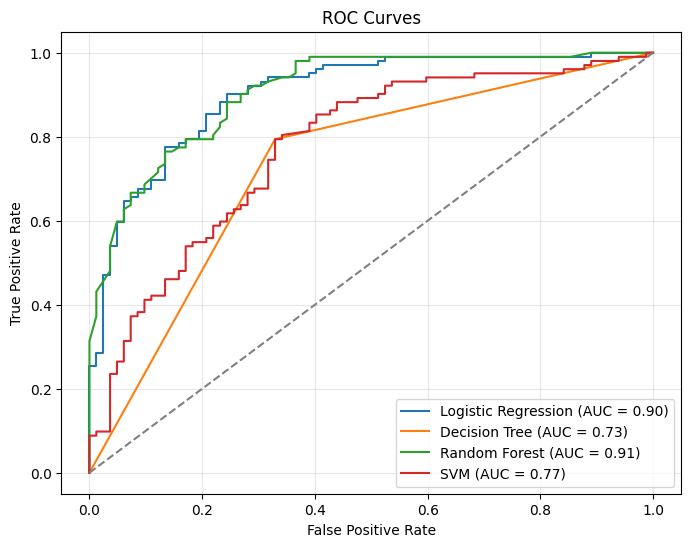

In [11]:
# ROC curves
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})")

plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()